**CRIME ANALYSIS**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as wtf

In [5]:
df = pd.read_csv('/content/crimes.csv')

In [6]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DR_NO         185715 non-null  int64 
 1   Date Rptd     185715 non-null  object
 2   DATE OCC      185715 non-null  object
 3   TIME OCC      185715 non-null  int64 
 4   AREA NAME     185715 non-null  object
 5   Crm Cd Desc   185715 non-null  object
 6   Vict Age      185715 non-null  int64 
 7   Vict Sex      185704 non-null  object
 8   Vict Descent  185705 non-null  object
 9   Weapon Desc   73502 non-null   object
 10  Status Desc   185715 non-null  object
 11  LOCATION      185715 non-null  object
dtypes: int64(3), object(9)
memory usage: 17.0+ MB


The `TIME OCC` column is currently an integer representing military time (e.g., `1110` for `11:10`). To convert it into a time structure, I will first convert it to a string, pad it with leading zeros to ensure a 4-digit format, and then parse it into a proper time object.

In [8]:
df['TIME OCC'] = df['TIME OCC'].astype(str).str.zfill(4)
df['TIME OCC'] = pd.to_datetime(df['TIME OCC'], format='%H%M').dt.time

print("Data types after converting 'TIME OCC' to time object:")
df.info()

Data types after converting 'TIME OCC' to time object:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DR_NO         185715 non-null  int64 
 1   Date Rptd     185715 non-null  object
 2   DATE OCC      185715 non-null  object
 3   TIME OCC      185715 non-null  object
 4   AREA NAME     185715 non-null  object
 5   Crm Cd Desc   185715 non-null  object
 6   Vict Age      185715 non-null  int64 
 7   Vict Sex      185704 non-null  object
 8   Vict Descent  185705 non-null  object
 9   Weapon Desc   73502 non-null   object
 10  Status Desc   185715 non-null  object
 11  LOCATION      185715 non-null  object
dtypes: int64(2), object(10)
memory usage: 17.0+ MB


In [9]:
display(df.head())

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,11:10:00,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,16:20:00,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,12:00:00,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,06:35:00,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,09:00:00,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


The `Date Rptd` and `DATE OCC` columns are currently of object type. Converting them to datetime objects will allow for proper time-series analysis.

In [10]:
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'])
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])

print("Data types after converting date columns:")
df.info()

Data types after converting date columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   DR_NO         185715 non-null  int64         
 1   Date Rptd     185715 non-null  datetime64[ns]
 2   DATE OCC      185715 non-null  datetime64[ns]
 3   TIME OCC      185715 non-null  object        
 4   AREA NAME     185715 non-null  object        
 5   Crm Cd Desc   185715 non-null  object        
 6   Vict Age      185715 non-null  int64         
 7   Vict Sex      185704 non-null  object        
 8   Vict Descent  185705 non-null  object        
 9   Weapon Desc   73502 non-null   object        
 10  Status Desc   185715 non-null  object        
 11  LOCATION      185715 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(8)
memory usage: 17.0+ MB


In [21]:
print(f"Shape of DataFrame before dropping duplicates: {df.shape}")

df.drop_duplicates(inplace=True)

print(f"Shape of DataFrame after dropping duplicates: {df.shape}")

Shape of DataFrame before dropping duplicates: (185715, 13)
Shape of DataFrame after dropping duplicates: (185715, 13)


In [12]:
df.isnull().sum()

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA NAME,0
Crm Cd Desc,0
Vict Age,0
Vict Sex,11
Vict Descent,10
Weapon Desc,112213


Based on the missing values count, I will drop the `Weapon Desc` column due to the high number of missing values. For `Vict Sex` and `Vict Descent`, I will fill the missing values with their respective modes.

In [16]:
# Drop the 'Weapon Desc' column due to a large number of missing values
if 'Weapon Desc' in df.columns:
    df = df.drop(columns=['Weapon Desc'])

# Fill missing values in 'Vict Sex' with its mode
vict_sex_mode = df['Vict Sex'].mode()[0]
df['Vict Sex'] = df['Vict Sex'].fillna(vict_sex_mode)

# Fill missing values in 'Vict Descent' with its mode
vict_descent_mode = df['Vict Descent'].mode()[0]
df['Vict Descent'] = df['Vict Descent'].fillna(vict_descent_mode)

print("Missing values after cleaning:")
df.isnull().sum()

Missing values after cleaning:


,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA NAME,0
Crm Cd Desc,0
Vict Age,0
Vict Sex,0
Vict Descent,0
Status Desc,0


In [14]:
display(df.head())

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,11:10:00,Southwest,THEFT OF IDENTITY,27,F,B,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,16:20:00,Olympic,THEFT OF IDENTITY,60,M,H,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,12:00:00,Hollywood,THEFT OF IDENTITY,28,M,H,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,06:35:00,77th Street,THEFT OF IDENTITY,37,M,H,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,09:00:00,Rampart,THEFT OF IDENTITY,79,M,B,Invest Cont,1200 W 7TH ST


### Crime Occurrences by Time of Day

This line plot visualizes the frequency of crimes throughout the day, based on the `TIME OCC` column. It helps in identifying peak hours for criminal activity.

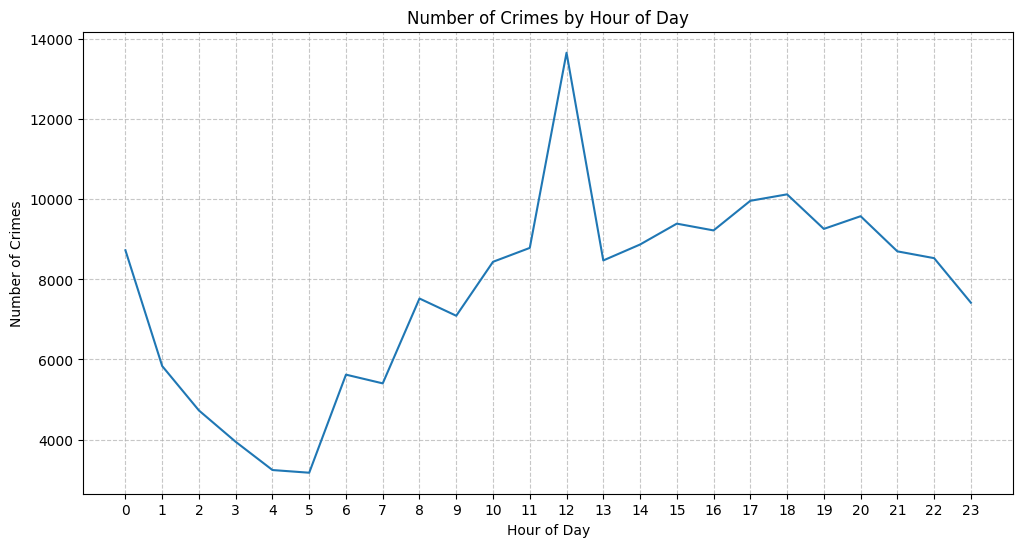

In [17]:
# Extract hour for plotting from TIME OCC (which is a time object)
df['Hour OCC'] = df['TIME OCC'].apply(lambda x: x.hour)

time_counts = df['Hour OCC'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=time_counts.index, y=time_counts.values)
plt.title('Number of Crimes by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Crimes')
plt.xticks(range(0, 24)) # Ensure all hours are displayed
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Crime Occurrences by Date

This line plot displays the trend of crime occurrences over time, using the `DATE OCC` column. This can reveal patterns, increases, or decreases in crime over the reporting period.

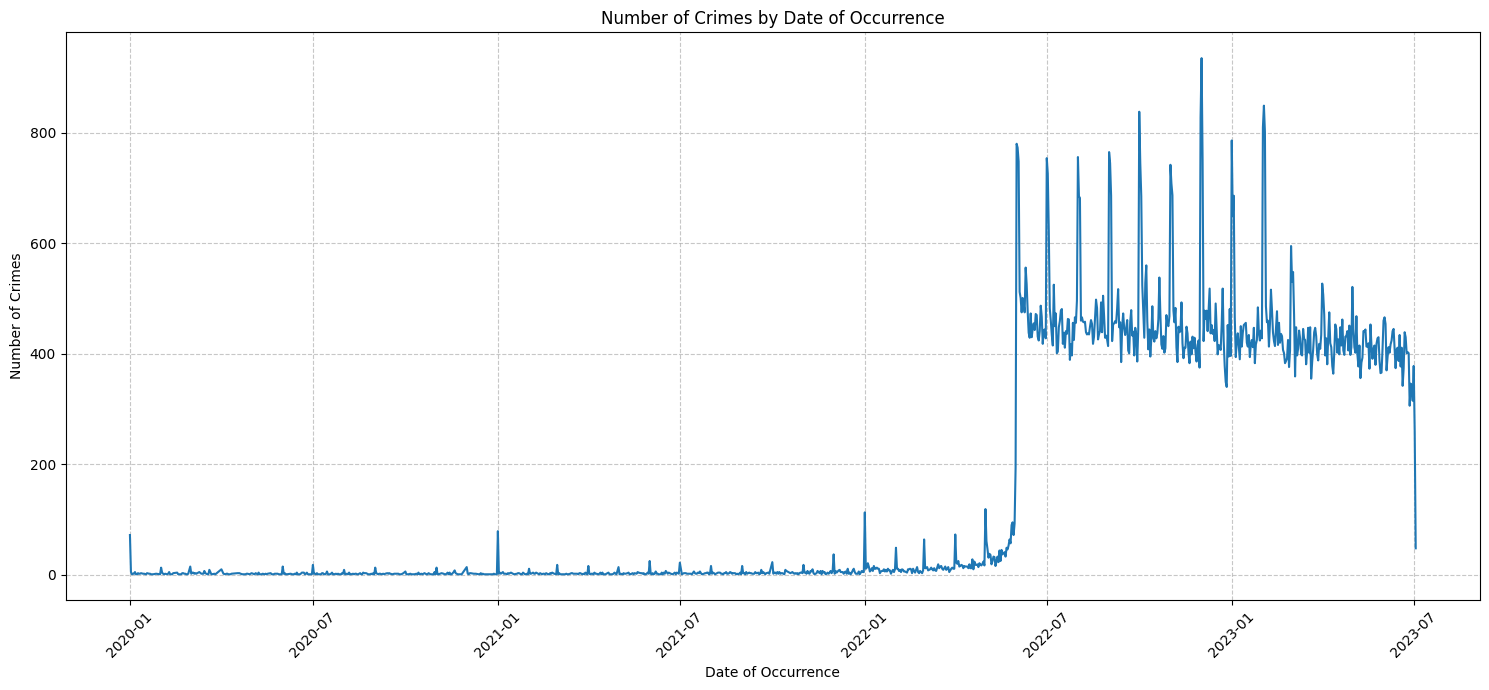

In [18]:
date_counts = df['DATE OCC'].value_counts().sort_index()

plt.figure(figsize=(15, 7))
sns.lineplot(x=date_counts.index, y=date_counts.values)
plt.title('Number of Crimes by Date of Occurrence')
plt.xlabel('Date of Occurrence')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Crime Reporting Delay Analysis

This histogram shows the distribution of the time difference between when a crime occurred (`DATE OCC`) and when it was reported (`Date Rptd`). A positive value indicates that the crime was reported after it occurred, and the magnitude indicates the delay in days. This can highlight reporting efficiencies or delays.

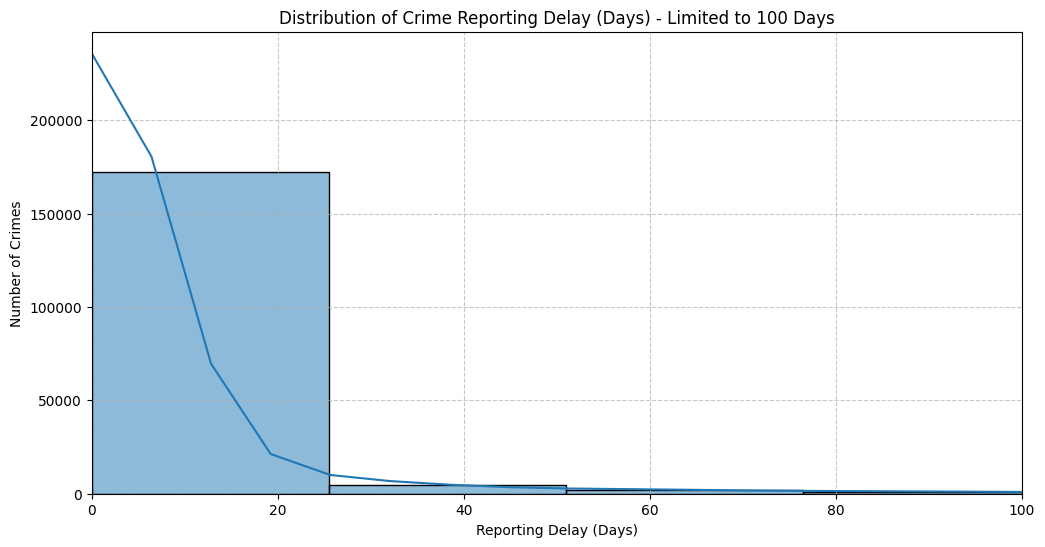

Reporting Delay Statistics:
count    185715.000000
mean         14.281593
std          76.651531
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max        1275.000000
Name: Reporting Delay, dtype: float64


In [20]:
df['Reporting Delay'] = (df['Date Rptd'] - df['DATE OCC']).dt.days

plt.figure(figsize=(12, 6))
sns.histplot(df['Reporting Delay'], bins=50, kde=True)
plt.title('Distribution of Crime Reporting Delay (Days) - Limited to 100 Days')
plt.xlabel('Reporting Delay (Days)')
plt.ylabel('Number of Crimes')
plt.xlim(0, 100) # Limit x-axis to 100 days
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Display some basic statistics for reporting delay
print("Reporting Delay Statistics:")
print(df['Reporting Delay'].describe())

### Crime Hotspots by Area

To identify crime hotspots, we'll analyze the frequency of crimes in each `AREA NAME`. This will give us an indication of which areas experience the most criminal activity.

In [22]:
area_crime_counts = df['AREA NAME'].value_counts().reset_index()
area_crime_counts.columns = ['AREA NAME', 'Crime Count']

print("Top 10 Crime Areas:")
display(area_crime_counts.head(10))

Top 10 Crime Areas:


,AREA NAME,Crime Count
0,Central,14944
1,Southwest,11945
2,77th Street,11739
3,Pacific,9923
4,Hollywood,9762
5,Southeast,9571
6,Olympic,9414
7,Newton,9152
8,Van Nuys,8621
9,N Hollywood,8502


Now, let's visualize these crime counts. Since direct geographic plotting requires detailed coordinate data for each area, which is not available in the current dataset, I will create a bar plot of the top 10 crime areas. If you have geographic boundary data (e.g., GeoJSON) for these areas, we could then use libraries like `folium` or `geopandas` to create an interactive map. For now, a bar chart will effectively show the areas with the highest crime frequencies.

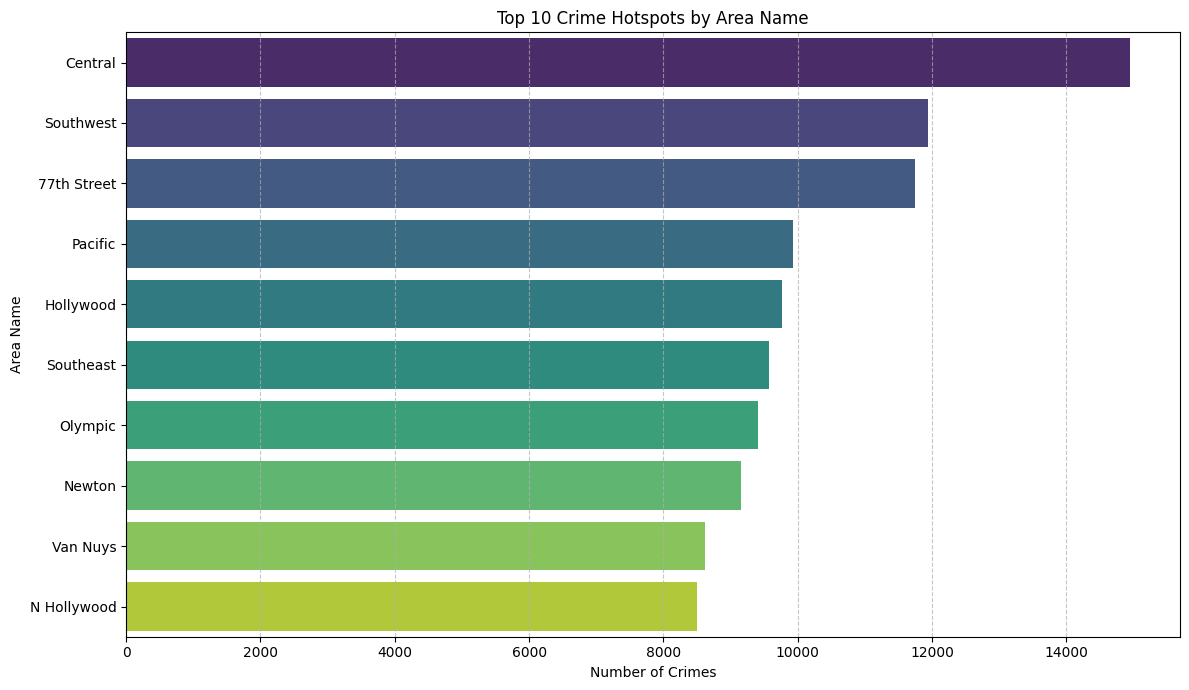

In [24]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Crime Count', y='AREA NAME', data=area_crime_counts.head(10), hue='AREA NAME', palette='viridis', legend=False)
plt.title('Top 10 Crime Hotspots by Area Name')
plt.xlabel('Number of Crimes')
plt.ylabel('Area Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [26]:
# =========================
# 1. Install libraries
# =========================
!pip install folium
import folium
from folium.plugins import HeatMap



# =========================
# 5. Group by AREA
# =========================
area_counts = df["AREA NAME"].value_counts().reset_index()
area_counts.columns = ["Area", "Crime Count"]

# =========================
# 6. Coordinates for areas (Los Angeles Police Areas)
# =========================
area_coords = {
    "Central": [34.05, -118.25],
    "Rampart": [34.06, -118.27],
    "Southwest": [34.01, -118.31],
    "Hollywood": [34.10, -118.33],
    "Harbor": [33.74, -118.29],
    "Wilshire": [34.06, -118.34],
    "West LA": [34.05, -118.45],
    "Van Nuys": [34.19, -118.45],
    "West Valley": [34.20, -118.55],
    "Northeast": [34.12, -118.20],
    "77th Street": [33.97, -118.27],
    "Newton": [34.00, -118.26],
    "Pacific": [33.99, -118.46],
    "North Hollywood": [34.17, -118.38],
    "Foothill": [34.27, -118.41],
    "Devonshire": [34.26, -118.53],
    "Mission": [34.27, -118.47],
    "Olympic": [34.05, -118.30],
    "Topanga": [34.20, -118.60],
    "Southeast": [33.94, -118.24],
    "Hollenbeck": [34.03, -118.21]
}

# =========================
# 7. Map areas to coordinates
# =========================
area_counts["lat"] = area_counts["Area"].map(lambda x: area_coords.get(x, [None, None])[0])
area_counts["lon"] = area_counts["Area"].map(lambda x: area_coords.get(x, [None, None])[1])

# Drop missing coords
area_counts = area_counts.dropna()

# =========================
# 8. Create map
# =========================
m = folium.Map(location=[34.05, -118.25], zoom_start=11)

# =========================
# 9. Prepare heatmap data
# =========================
heat_data = area_counts[["lat", "lon", "Crime Count"]].values.tolist()

# =========================
# 10. Add heatmap
# =========================
HeatMap(heat_data, radius=25).add_to(m)

# =========================
# 11. Add markers (optional but looks nice)
# =========================
for _, row in area_counts.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=5,
        popup=f"{row['Area']} - {row['Crime Count']} crimes",
        fill=True
    ).add_to(m)

# =========================
# 12. Display map
# =========================
m

### Percentage of Solved Crimes

This pie chart visualizes the proportion of crimes that are considered 'Solved' versus 'Unsolved' based on the `Status Desc` column. Crimes with statuses like 'Adult Arrest' and 'Juvenile Arrest' are categorized as 'Solved', while others are considered 'Unsolved' or 'Investigation Continued'.

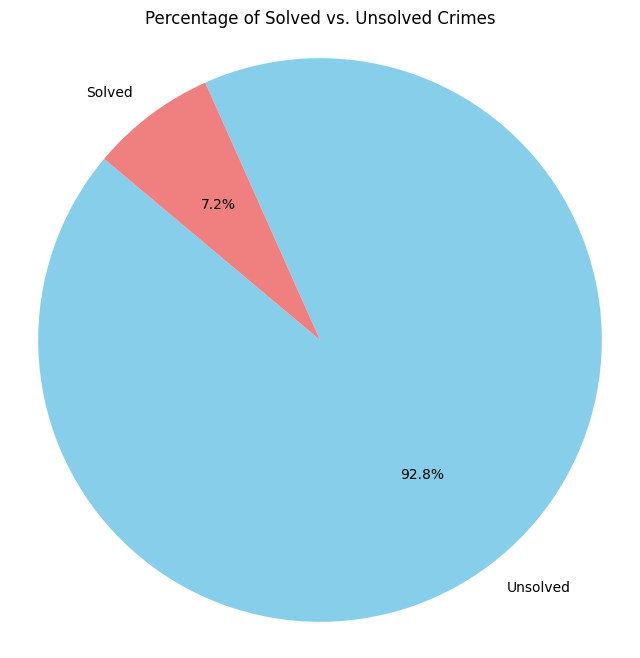

Crime Status Category Distribution:


,count
Crime Status Category,
Unsolved,92.786259
Solved,7.213741


In [32]:
# Categorize 'Status Desc' into 'Solved' and 'Unsolved'
solved_statuses = ['Adult Arrest', 'Juvenile Arrest']

df['Crime Status Category'] = df['Status Desc'].apply(lambda x: 'Solved' if x in solved_statuses else 'Unsolved')

# Calculate percentages
status_counts = df['Crime Status Category'].value_counts()
status_percentages = status_counts / status_counts.sum() * 100

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(status_percentages, labels=status_percentages.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightcoral'])
plt.title('Percentage of Solved vs. Unsolved Crimes')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

print("Crime Status Category Distribution:")
display(status_percentages)

### Top Crimes by Hour in Top 3 Areas

This visualization identifies the top 3 crime areas and, for each of these areas, it then identifies the most frequent crime types. A faceted bar chart is then used to display the hourly distribution of these top crimes within their respective top areas. This helps to pinpoint specific crime hotspots and their characteristic time patterns.

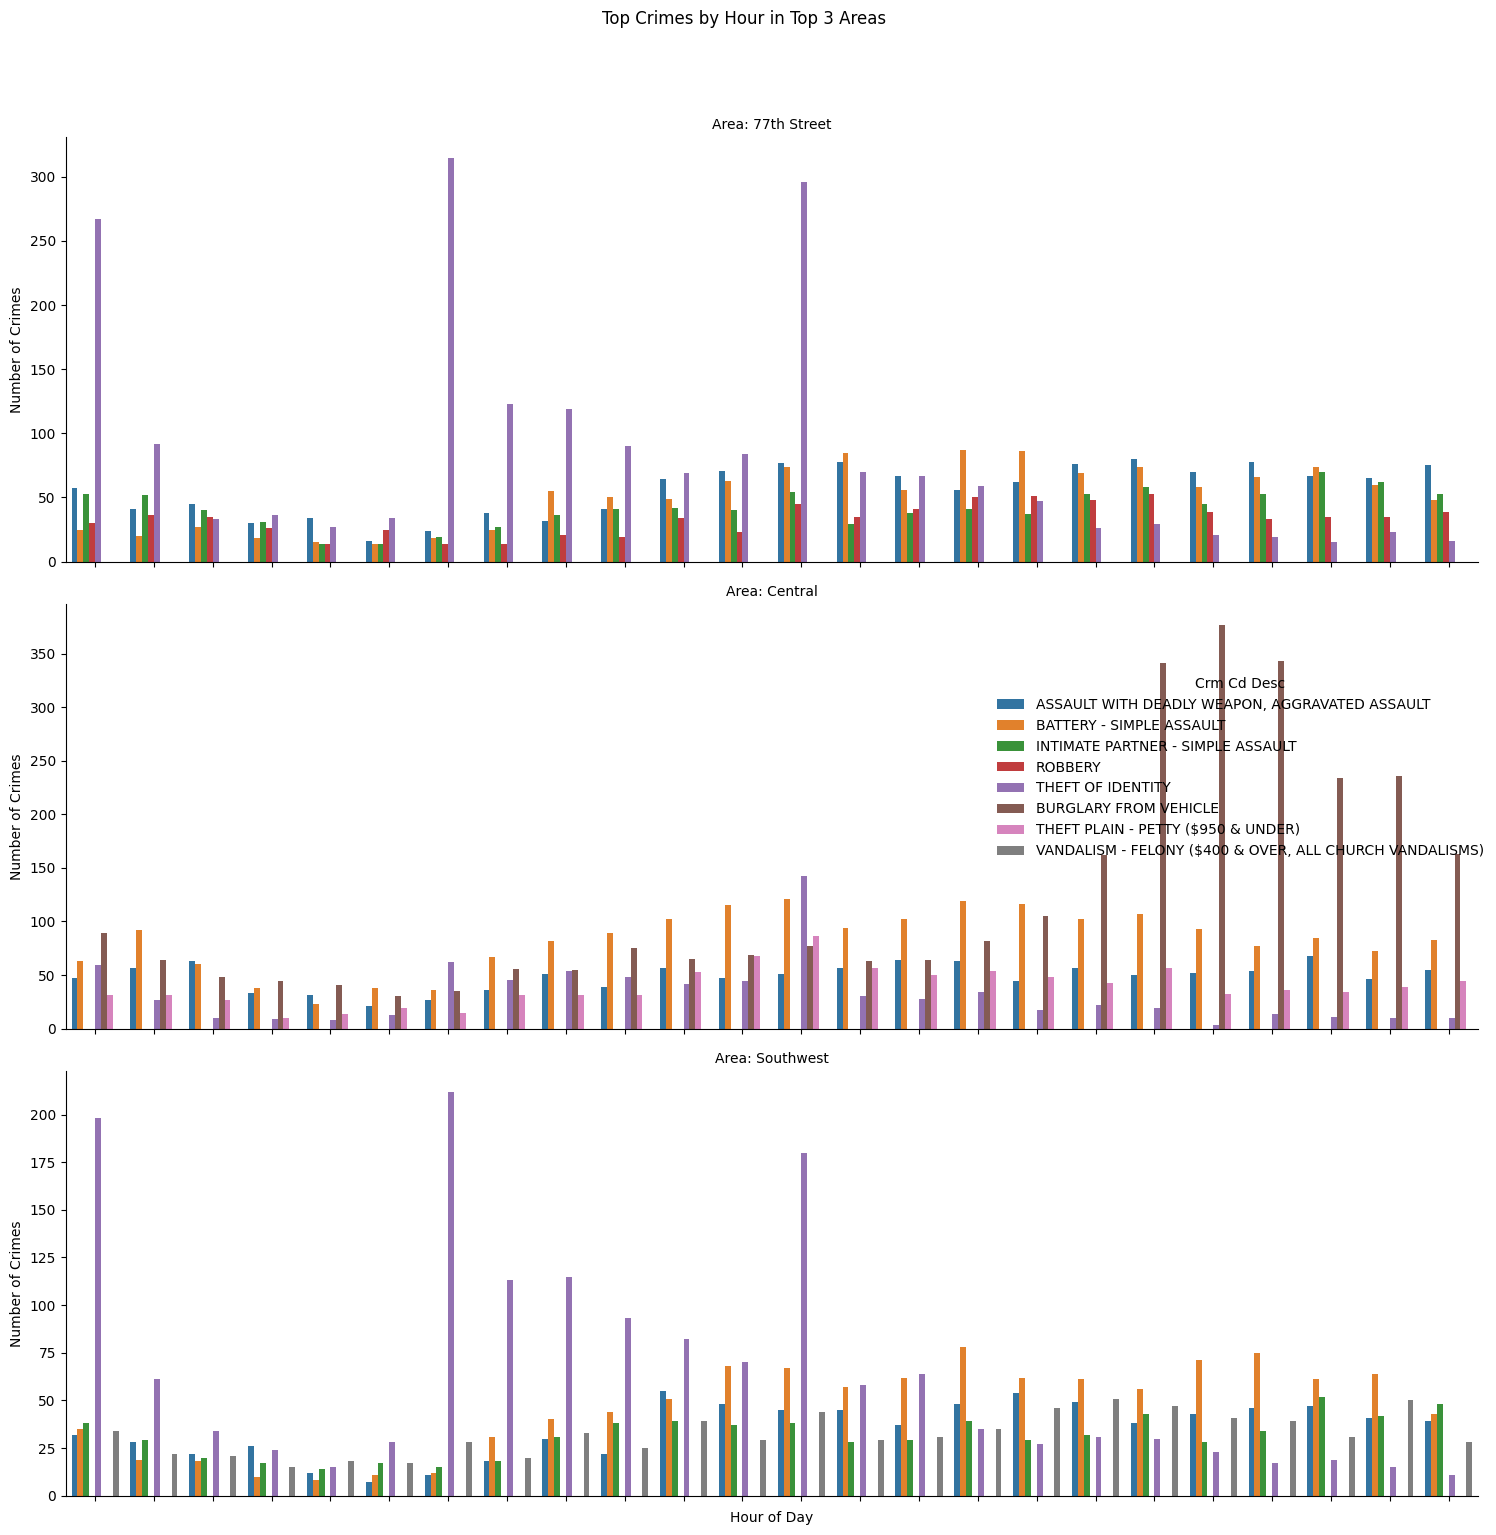

In [33]:
# 1. Get the top 3 crime areas
top_3_areas = df['AREA NAME'].value_counts().nlargest(3).index.tolist()

# 2. Filter the DataFrame for these areas
df_top_3_areas = df[df['AREA NAME'].isin(top_3_areas)].copy()

# 3. For each of these top 3 areas, find the top crimes (e.g., top 5 crimes per area)
top_crimes_per_area = {}
for area in top_3_areas:
    crimes_in_area = df_top_3_areas[df_top_3_areas['AREA NAME'] == area]
    top_5_crimes = crimes_in_area['Crm Cd Desc'].value_counts().nlargest(5).index.tolist()
    top_crimes_per_area[area] = top_5_crimes

# Now, filter df_top_3_areas further to only include these top crimes
filtered_for_plot = pd.DataFrame()
for area, crimes_list in top_crimes_per_area.items():
    temp_df = df_top_3_areas[(df_top_3_areas['AREA NAME'] == area) & (df_top_3_areas['Crm Cd Desc'].isin(crimes_list))]
    filtered_for_plot = pd.concat([filtered_for_plot, temp_df])

# 4. Prepare data for plotting: Number of crimes by hour for top crimes in top 3 areas
plot_data = filtered_for_plot.groupby(['AREA NAME', 'Crm Cd Desc', 'Hour OCC']).size().reset_index(name='Crime Count')

# Plot using catplot
g = sns.catplot(
    data=plot_data,
    x='Hour OCC',
    y='Crime Count',
    hue='Crm Cd Desc',
    col='AREA NAME',
    kind='bar',
    col_wrap=1, # Display columns in a single row
    height=5, aspect=2,
    palette='tab10', # A different palette for distinct crime types
    sharey=False # Allow each facet to have its own y-axis scale
)

g.set_axis_labels("Hour of Day", "Number of Crimes")
g.set_titles("Area: {col_name}")
g.set_xticklabels(rotation=45, ha='right')
g.set(xticks=range(0, 24)) # Ensure all hours are displayed
plt.suptitle('Top Crimes by Hour in Top 3 Areas', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

#### 1. Distribution of Victims by Sex

This bar plot shows the total number of male, female, and unknown victims, providing an overview of the gender distribution among reported crime victims.

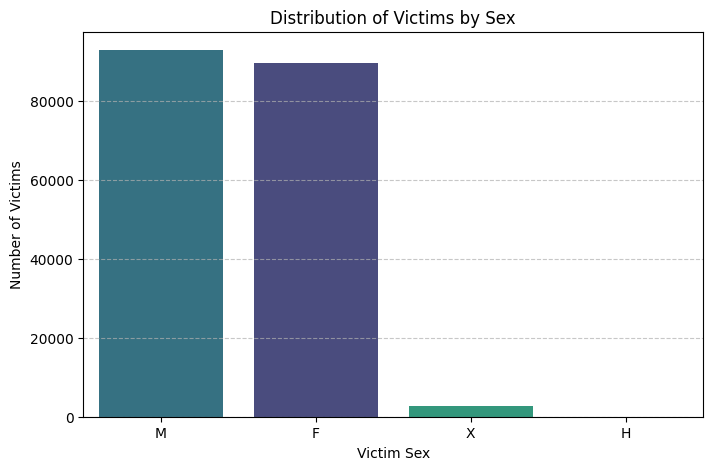

In [31]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Vict Sex', hue='Vict Sex', palette='viridis', order=df['Vict Sex'].value_counts().index, legend=False)
plt.title('Distribution of Victims by Sex')
plt.xlabel('Victim Sex')
plt.ylabel('Number of Victims')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### 2. Number of Victims by Sex and Age Group

This stacked bar plot visualizes the breakdown of victims by age group, further separated by their sex. This helps in understanding which age demographics are more affected within each gender.

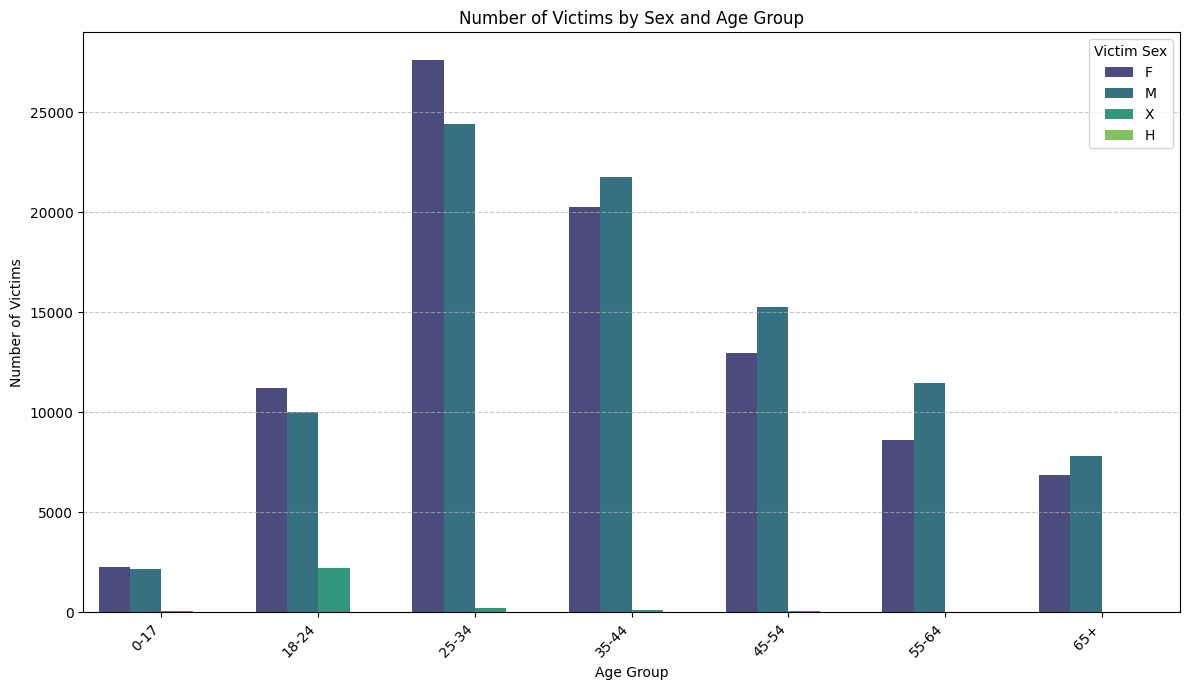

In [29]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='Age Group', hue='Vict Sex', palette='viridis',
              order=labels) # Ensure age groups are ordered correctly
plt.title('Number of Victims by Sex and Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Victims')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Victim Sex')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 3. Number of Victims by Sex, Age Group, and Top 5 Descents

This faceted bar chart provides a detailed view of victim demographics, breaking down crime counts by victim sex, age group, and the top 5 most frequent victim descents. This allows for a deeper analysis into specific demographic segments.

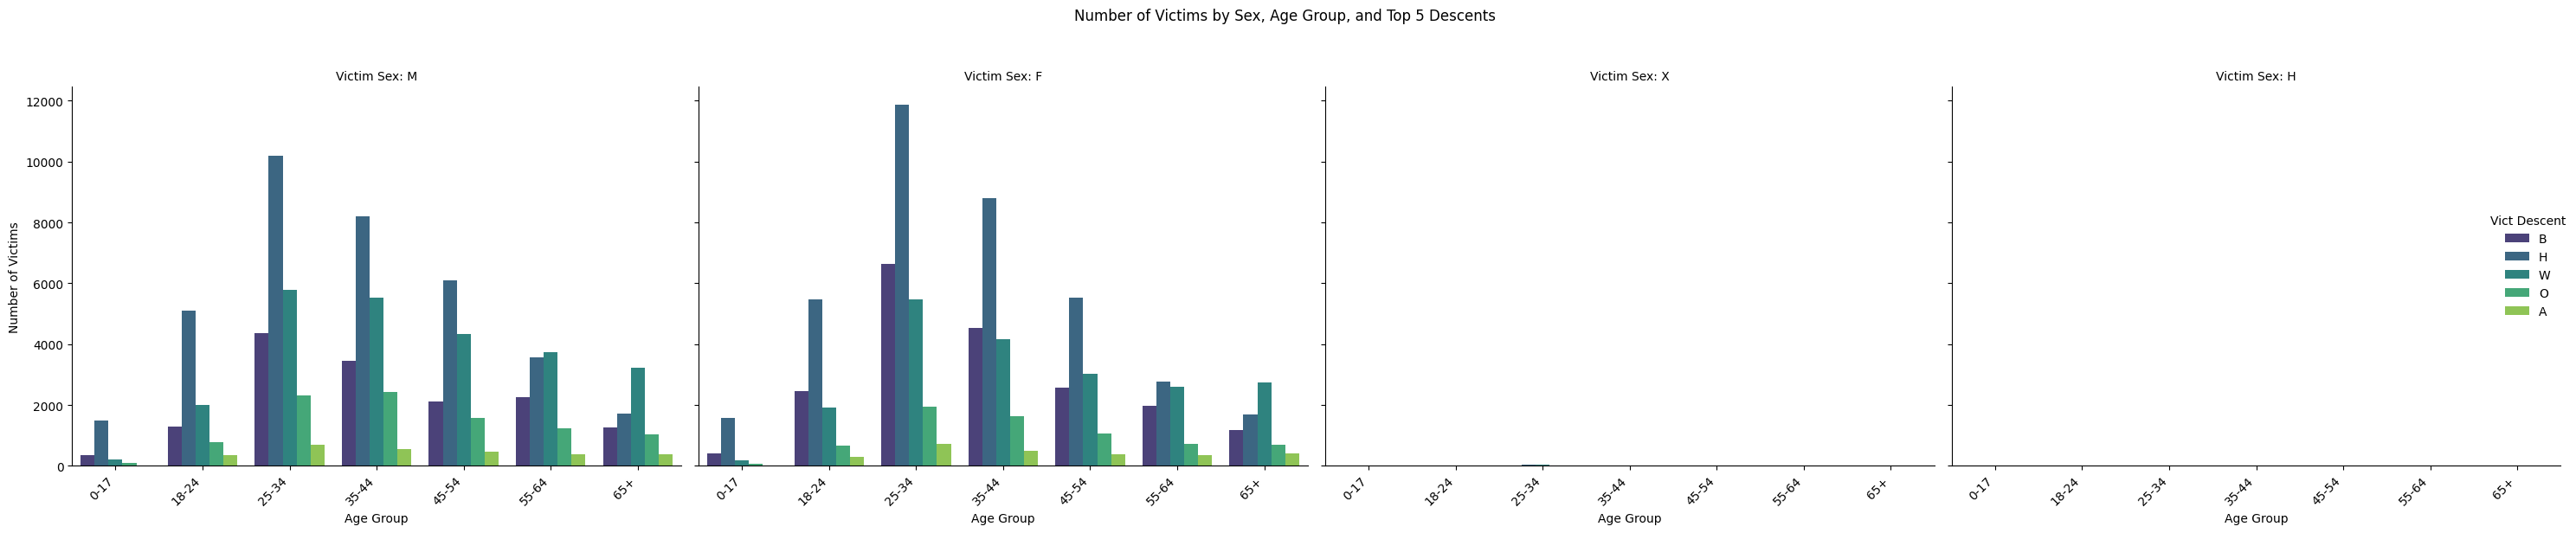

In [30]:
# Get the top N descents for clearer visualization
top_descents = df['Vict Descent'].value_counts().nlargest(5).index.tolist()
df_filtered_descent = df[df['Vict Descent'].isin(top_descents)]

g = sns.catplot(data=df_filtered_descent, x='Age Group', hue='Vict Descent', col='Vict Sex',
                kind='count', height=6, aspect=1.2, palette='viridis',
                col_order=df['Vict Sex'].value_counts().index, # Order male/female columns
                order=labels) # Order age groups on x-axis

g.set_axis_labels("Age Group", "Number of Victims")
g.set_titles("Victim Sex: {col_name}")
g.set_xticklabels(rotation=45, ha='right')
plt.suptitle('Number of Victims by Sex, Age Group, and Top 5 Descents', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()